# Complete Text-to-Image Generation Pipeline

## Internship Project

This project presents a complete text-to-image generation pipeline using
Generative AI, GANs, text embeddings, attention mechanisms, and image
generation techniques.

## Objective
To develop a comprehensive text-to-image generation pipeline by integrating
the techniques implemented in Tasks 1–6.

##Method

The project combines text preprocessing, text embedding, conditional GAN-based image generation, attention mechanisms, and Stable Diffusion with LoRA fine-tuning. Text descriptions are converted into embeddings and used for conditioning image generation, while attention mechanisms help the model focus on relevant information. The individual components are implemented and tested as an integrated text-to-image workflow.

### Tasks Covered
1. Fine-tuning a pretrained text-to-image model
2. Conditional GAN (CGAN)
3. Text tokenization and text embeddings
4. Oxford Flowers dataset exploration
5. Attention mechanism in GAN
6. Complete text-to-image generation pipeline

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Integration project started")
print("Device:", device)

Integration project started
Device: cuda


## Task 1 – Stable Diffusion with LoRA

A pretrained Stable Diffusion model was adapted using LoRA on a custom
image dataset. The trained LoRA weights are used here to generate
domain-specific images from text prompts.

In [ ]:
!pip install -q diffusers==0.40.0 transformers==5.2.0 accelerate==1.10.1 peft==0.18.0 safetensors datasets

In [ ]:
import torch
import diffusers
import transformers
import peft
import accelerate

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("PyTorch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)

GPU: Tesla T4
PyTorch: 2.11.0+cu130
Diffusers: 0.40.0
Transformers: 5.2.0
PEFT: 0.18.0
Accelerate: 1.10.1


In [ ]:
# Task 1: Load custom dataset

from datasets import load_dataset
import os

dataset = load_dataset("huggan/pokemon", split="train")

dataset_path = "/content/custom_dataset/train"
os.makedirs(dataset_path, exist_ok=True)

for i in range(100):
    image = dataset[i]["image"].convert("RGB")
    image.save(f"{dataset_path}/pokemon_{i}.jpg")

with open(f"{dataset_path}/metadata.jsonl", "w") as f:
    for i in range(100):
        f.write(
            '{"file_name": "pokemon_' + str(i) +
            '.jpg", "text": "a colorful cartoon Pokemon character, digital artwork"}\n'
        )

print("Custom dataset created successfully!")
print("Images:", len([x for x in os.listdir(dataset_path) if x.endswith(".jpg")]))

Repo card metadata block was not found. Setting CardData to empty.


Custom dataset created successfully!
Images: 100


In [ ]:
# Task 1: Load pretrained Stable Diffusion

import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion loaded successfully!


  0%|          | 0/20 [00:00<?, ?it/s]

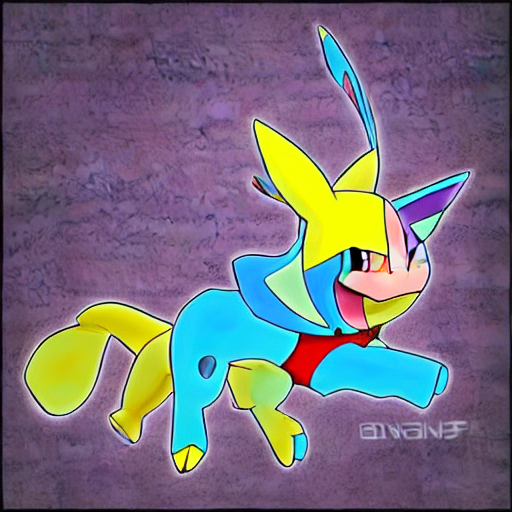

In [ ]:
# Task 1: Generate a baseline image

prompt = "a colorful cartoon Pokemon character, digital artwork"

image = pipe(
    prompt,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

display(image)

In [ ]:
# Task 1: Download the matching Diffusers 0.40.0 LoRA script

!wget -q -O /content/train_text_to_image_lora.py \
https://raw.githubusercontent.com/huggingface/diffusers/v0.40.0/examples/text_to_image/train_text_to_image_lora.py

print("Matching LoRA training script downloaded successfully!")

Matching LoRA training script downloaded successfully!


In [ ]:
!accelerate launch /content/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/content/custom_dataset/train" \
  --caption_column="text" \
  --resolution=512 \
  --center_crop \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --gradient_checkpointing \
  --mixed_precision="fp16" \
  --max_train_steps=100 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --output_dir="/content/pokemon-lora" \
  --checkpointing_steps=100 \
  --rank=4 \
  --seed=42

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
INFO:__main__:Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https

In [ ]:
import os

print("Task 1 LoRA output:")
print(os.listdir("/content/pokemon-lora"))

Task 1 LoRA output:
['pytorch_lora_weights.safetensors', 'checkpoint-100', 'logs']


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/25 [00:00<?, ?it/s]

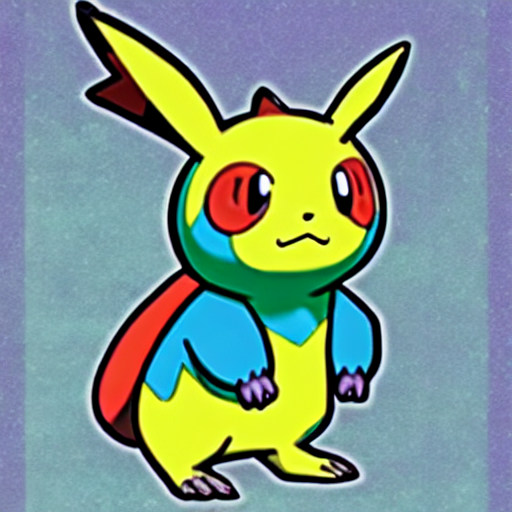

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("/content/pokemon-lora")

prompt = "a colorful Pokemon character, cartoon digital artwork"

image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

display(image)

## Task 2 – Conditional GAN for Text-Conditioned Image Generation

In this step, a Conditional Generative Adversarial Network (CGAN) is used
to generate images based on input categories.

The generator receives random noise together with the condition information,
while the discriminator evaluates whether the generated image matches the
given condition.

The trained model can generate different shapes such as square, triangle,
and circle according to the specified condition.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import random

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Image settings
IMG_SIZE = 28
NUM_IMAGES_PER_CLASS = 1000

# Class labels
shape_names = {
    0: "Circle",
    1: "Square",
    2: "Triangle"
}

images = []
labels = []

def create_shape(shape_type):
    # Create black image
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
    draw = ImageDraw.Draw(img)

    # Random position and size
    size = random.randint(12, 20)
    x = random.randint(3, IMG_SIZE - size - 3)
    y = random.randint(3, IMG_SIZE - size - 3)

    if shape_type == 0:
        # Circle
        draw.ellipse(
            [x, y, x + size, y + size],
            fill=255
        )

    elif shape_type == 1:
        # Square
        draw.rectangle(
            [x, y, x + size, y + size],
            fill=255
        )

    elif shape_type == 2:
        # Triangle
        draw.polygon(
            [
                (x + size // 2, y),
                (x, y + size),
                (x + size, y + size)
            ],
            fill=255
        )

    return np.array(img)

# Generate dataset
for label in range(3):
    for i in range(NUM_IMAGES_PER_CLASS):
        img = create_shape(label)

        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Dataset created successfully!")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Dataset created successfully!
Images shape: (3000, 28, 28)
Labels shape: (3000,)


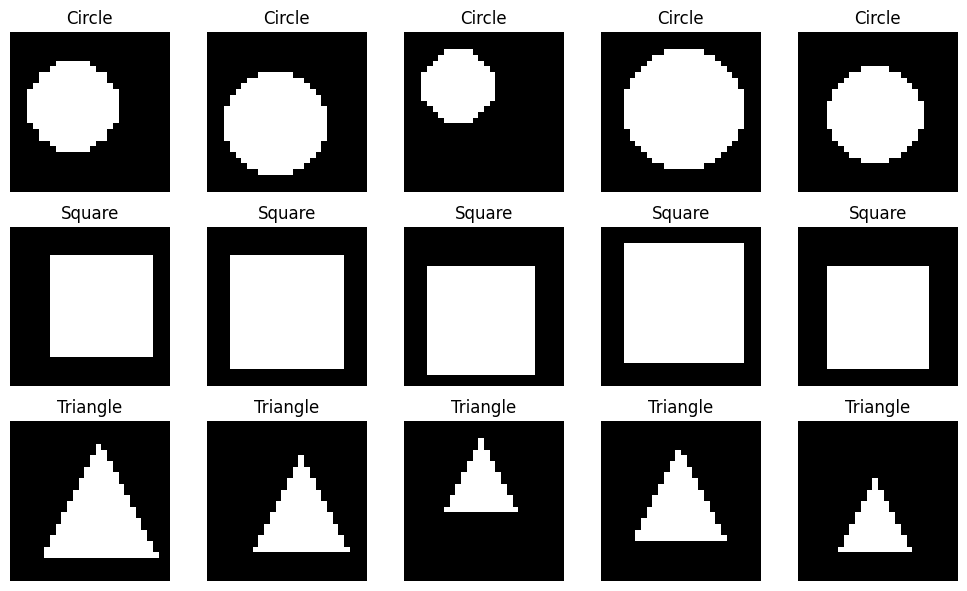

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for label in range(3):
    indices = np.where(labels == label)[0][:5]

    for j, idx in enumerate(indices):
        axes[label, j].imshow(images[idx], cmap="gray")
        axes[label, j].axis("off")
        axes[label, j].set_title(shape_names[label])

plt.tight_layout()
plt.show()

In [ ]:
# Normalize images from [0, 255] to [-1, 1]
images_tensor = torch.tensor(images, dtype=torch.float32)

images_tensor = images_tensor / 127.5 - 1.0

# Add channel dimension: (3000, 28, 28) -> (3000, 1, 28, 28)
images_tensor = images_tensor.unsqueeze(1)

# Convert labels to tensor
labels_tensor = torch.tensor(labels, dtype=torch.long)

print("Images tensor shape:", images_tensor.shape)
print("Labels tensor shape:", labels_tensor.shape)

Images tensor shape: torch.Size([3000, 1, 28, 28])
Labels tensor shape: torch.Size([3000])


In [ ]:
# Create dataset
dataset = torch.utils.data.TensorDataset(
    images_tensor,
    labels_tensor
)

# Create DataLoader
batch_size = 64

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("DataLoader created successfully!")
print("Number of batches:", len(dataloader))

DataLoader created successfully!
Number of batches: 47


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
class Generator(nn.Module):
    def _init_(self, noise_dim=100, num_classes=3):
        super(Generator, self)._init_()

        self.label_embedding = nn.Embedding(
            num_classes,
            10
        )

        self.model = nn.Sequential(
            nn.Linear(noise_dim + 10, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Convert labels into embeddings
        label_embedding = self.label_embedding(labels)

        # Combine noise and label information
        combined = torch.cat(
            [noise, label_embedding],
            dim=1
        )

        # Generate image
        output = self.model(combined)

        # Reshape to image format
        output = output.view(
            output.size(0),
            1,
            28,
            28
        )

        return output


# Create Generator
generator = Generator().to(device)

print("Generator created successfully!")

Generator created successfully!


In [ ]:
class Discriminator(nn.Module):
    def _init_(self, num_classes=3):
        super(Discriminator, self)._init_()

        # Convert class label into an image-sized representation
        self.label_embedding = nn.Embedding(
            num_classes,
            28 * 28
        )

        self.model = nn.Sequential(
            nn.Linear(28 * 28 * 2, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):

        # Convert labels into a vector
        label_embedding = self.label_embedding(labels)

        # Flatten image
        image_flat = image.view(
            image.size(0),
            -1
        )

        # Combine image and label
        combined = torch.cat(
            [image_flat, label_embedding],
            dim=1
        )

        # Decide real or fake
        output = self.model(combined)

        return output


# Create Discriminator
discriminator = Discriminator().to(device)

print("Discriminator created successfully!")

Discriminator created successfully!


In [ ]:
import torch
import torch.nn as nn

layer = nn.Linear(10, 5)

print("Layer:", layer)
print("Number of parameters:", len(list(layer.parameters())))

for name, param in layer.named_parameters():
    print(name, param.shape)

Layer: Linear(in_features=10, out_features=5, bias=True)
Number of parameters: 2
weight torch.Size([5, 10])
bias torch.Size([5])


In [ ]:
import torch
import torch.nn as nn

# Number of random noise values
noise_dim = 100

# Number of shape classes
num_classes = 3

# ============================
# GENERATOR
# ============================

generator = nn.Sequential(
    nn.Linear(noise_dim + num_classes, 128),
    nn.ReLU(),

    nn.Linear(128, 256),
    nn.ReLU(),

    nn.Linear(256, 512),
    nn.ReLU(),

    nn.Linear(512, 28 * 28),
    nn.Tanh()
).to(device)


# ============================
# DISCRIMINATOR
# ============================

discriminator = nn.Sequential(
    nn.Linear(28 * 28 + num_classes, 512),
    nn.LeakyReLU(0.2),

    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),

    nn.Linear(256, 1),
    nn.Sigmoid()
).to(device)


print("Generator created successfully!")
print("Generator parameters:",
      len(list(generator.parameters())))

print()

print("Discriminator created successfully!")
print("Discriminator parameters:",
      len(list(discriminator.parameters())))

Generator created successfully!
Generator parameters: 8

Discriminator created successfully!
Discriminator parameters: 6


In [ ]:
# Create random noise
test_noise = torch.randn(
    6,
    noise_dim,
    device=device
)

# Labels:
# 0 = Circle
# 1 = Square
# 2 = Triangle
test_labels = torch.tensor(
    [0, 0, 1, 1, 2, 2],
    device=device
)

# Convert labels to one-hot vectors
test_one_hot = torch.zeros(
    6,
    num_classes,
    device=device
)

test_one_hot.scatter_(
    1,
    test_labels.unsqueeze(1),
    1
)

# Combine noise + label
generator_input = torch.cat(
    [test_noise, test_one_hot],
    dim=1
)

# Generate images
with torch.no_grad():
    generated = generator(generator_input)

generated = generated.view(
    6, 1, 28, 28
)

print("Generated image shape:", generated.shape)

Generated image shape: torch.Size([6, 1, 28, 28])


In [ ]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [ ]:
# Improved Conditional Discriminator

discriminator = nn.Sequential(
    nn.Linear(28 * 28 + 3, 1024),
    nn.LeakyReLU(0.2),

    nn.Linear(1024, 512),
    nn.LeakyReLU(0.2),

    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),

    nn.Linear(256, 1),
    nn.Sigmoid()
).to(device)

# Recreate discriminator optimizer
optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0001,
    betas=(0.5, 0.999)
)

print("Improved discriminator created successfully!")

Improved discriminator created successfully!


In [ ]:
# Stronger Conditional GAN

noise_dim = 100
num_classes = 3

# Generator
generator = nn.Sequential(
    nn.Linear(noise_dim + num_classes, 256),
    nn.LeakyReLU(0.2),

    nn.Linear(256, 512),
    nn.LeakyReLU(0.2),

    nn.Linear(512, 1024),
    nn.LeakyReLU(0.2),

    nn.Linear(1024, 28 * 28),
    nn.Tanh()
).to(device)


# Discriminator
discriminator = nn.Sequential(
    nn.Linear(28 * 28 + num_classes, 1024),
    nn.LeakyReLU(0.2),

    nn.Linear(1024, 512),
    nn.LeakyReLU(0.2),

    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),

    nn.Linear(256, 1),
    nn.Sigmoid()
).to(device)


criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("New CGAN created successfully!")
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in discriminator.parameters()))

New CGAN created successfully!
Generator parameters: 1487120
Discriminator parameters: 1463297


In [ ]:
num_epochs = 180

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for real_images, real_labels in dataloader:

        real_images = real_images.to(device)
        real_labels = real_labels.to(device)

        batch_size = real_images.size(0)

        # One-hot encode real labels
        real_labels_onehot = torch.zeros(
            batch_size, num_classes, device=device
        )
        real_labels_onehot.scatter_(
            1, real_labels.unsqueeze(1), 1
        )

        # =========================
        # Train Discriminator
        # =========================

        optimizer_D.zero_grad()

        real_flat = real_images.view(batch_size, -1)

        real_input = torch.cat(
            [real_flat, real_labels_onehot], dim=1
        )

        real_output = discriminator(real_input)

        real_loss = criterion(
            real_output,
            torch.ones(batch_size, 1, device=device)
        )

        # Generate fake images
        noise = torch.randn(
            batch_size, noise_dim, device=device
        )

        fake_labels = torch.randint(
            0, num_classes,
            (batch_size,),
            device=device
        )

        fake_labels_onehot = torch.zeros(
            batch_size, num_classes, device=device
        )

        fake_labels_onehot.scatter_(
            1, fake_labels.unsqueeze(1), 1
        )

        fake_images = generator(
            torch.cat(
                [noise, fake_labels_onehot],
                dim=1
            )
        )

        fake_input = torch.cat(
            [fake_images.detach(), fake_labels_onehot],
            dim=1
        )

        fake_output = discriminator(fake_input)

        fake_loss = criterion(
            fake_output,
            torch.zeros(batch_size, 1, device=device)
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # =========================
        # Train Generator
        # =========================

        optimizer_G.zero_grad()

        fake_input = torch.cat(
            [fake_images, fake_labels_onehot],
            dim=1
        )

        output = discriminator(fake_input)

        g_loss = criterion(
            output,
            torch.ones(batch_size, 1, device=device)
        )

        g_loss.backward()
        optimizer_G.step()

    G_losses.append(g_loss.item())
    D_losses.append(d_loss.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

print("\nCGAN training completed successfully! 🎉")

Epoch [1/180] | D Loss: 0.6781 | G Loss: 1.5025
Epoch [2/180] | D Loss: 0.6876 | G Loss: 1.7383
Epoch [3/180] | D Loss: 0.6231 | G Loss: 1.4977
Epoch [4/180] | D Loss: 0.4863 | G Loss: 2.2217
Epoch [5/180] | D Loss: 0.4644 | G Loss: 2.0044
Epoch [6/180] | D Loss: 0.9697 | G Loss: 6.6476
Epoch [7/180] | D Loss: 0.2571 | G Loss: 2.2664
Epoch [8/180] | D Loss: 0.1709 | G Loss: 3.8716
Epoch [9/180] | D Loss: 0.4083 | G Loss: 2.2075
Epoch [10/180] | D Loss: 0.7160 | G Loss: 1.1713
Epoch [11/180] | D Loss: 0.5070 | G Loss: 2.4126
Epoch [12/180] | D Loss: 0.3005 | G Loss: 2.7267
Epoch [13/180] | D Loss: 0.4215 | G Loss: 2.2722
Epoch [14/180] | D Loss: 0.3878 | G Loss: 4.0609
Epoch [15/180] | D Loss: 0.1112 | G Loss: 3.3392
Epoch [16/180] | D Loss: 0.0240 | G Loss: 5.5723
Epoch [17/180] | D Loss: 0.8103 | G Loss: 2.1046
Epoch [18/180] | D Loss: 0.7711 | G Loss: 2.4100
Epoch [19/180] | D Loss: 0.7812 | G Loss: 2.7284
Epoch [20/180] | D Loss: 0.6905 | G Loss: 1.8059
Epoch [21/180] | D Loss: 0.60

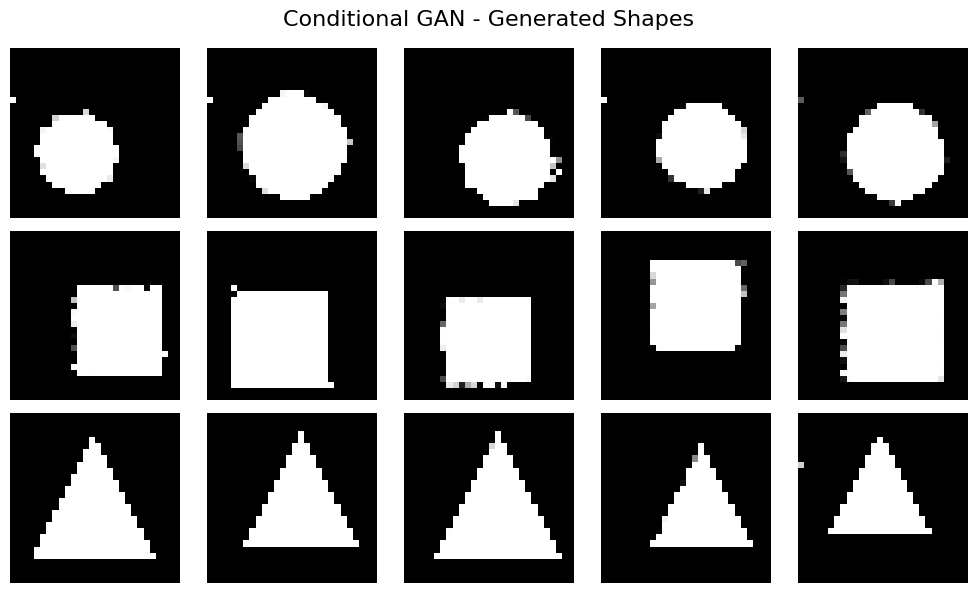

In [ ]:
generator.eval()

class_names = ["Circle", "Square", "Triangle"]
num_samples = 5

fig, axes = plt.subplots(
    3, num_samples,
    figsize=(10, 6)
)

with torch.no_grad():

    for class_id in range(3):

        labels = torch.full(
            (num_samples,),
            class_id,
            dtype=torch.long,
            device=device
        )

        labels_onehot = torch.zeros(
            num_samples,
            num_classes,
            device=device
        )

        labels_onehot.scatter_(
            1,
            labels.unsqueeze(1),
            1
        )

        noise = torch.randn(
            num_samples,
            noise_dim,
            device=device
        )

        generated = generator(
            torch.cat(
                [noise, labels_onehot],
                dim=1
            )
        )

        generated = generated.view(
            num_samples, 28, 28
        ).cpu()

        for i in range(num_samples):

            axes[class_id, i].imshow(
                generated[i],
                cmap="gray"
            )

            axes[class_id, i].axis("off")

        axes[class_id, 0].set_ylabel(
            class_names[class_id],
            fontsize=12
        )

plt.suptitle(
    "Conditional GAN - Generated Shapes",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
torch.save(generator.state_dict(), "task2_generator.pth")

print("Generator saved successfully!")

Generator saved successfully!


## Task 3 – Text Preprocessing and Text Embedding

In this step, the input text prompt is processed using the CLIP tokenizer.
The tokenized text is then passed through the CLIP text encoder to obtain
a numerical text embedding.

This embedding represents the semantic information of the text and is
used as the text-conditioning information for image generation.

In [ ]:
!pip install -q transformers torch

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("Tokenizer loaded successfully!")

Tokenizer loaded successfully!


In [ ]:
texts = [
    "A red square on a white background",
    "A blue circle on a white background",
    "A small green tree in a garden"
]

tokens = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print("Text descriptions:")
for text in texts:
    print("-", text)

print("\nTokenization completed successfully!")
print("Input IDs shape:", tokens["input_ids"].shape)
print("Attention mask shape:", tokens["attention_mask"].shape)

Text descriptions:
- A red square on a white background
- A blue circle on a white background
- A small green tree in a garden

Tokenization completed successfully!
Input IDs shape: torch.Size([3, 9])
Attention mask shape: torch.Size([3, 9])


In [ ]:
import torch
from transformers import CLIPTextModel

text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

text_encoder.eval()

with torch.no_grad():
    outputs = text_encoder(
        input_ids=tokens["input_ids"],
        attention_mask=tokens["attention_mask"]
    )

embeddings = outputs.last_hidden_state

print("Text encoding completed successfully!")
print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.pre_layrnorm.weight                               | UNEXPECTED |  | 
vision_model.embeddings.position_embe

Text encoding completed successfully!
Embedding shape: torch.Size([3, 9, 512])


In [ ]:
# Check the generated embeddings

print("Number of text descriptions:", len(texts))
print("Embedding shape:", embeddings.shape)
print("Embedding data type:", embeddings.dtype)

# Display a small portion of the first embedding
print("\nFirst text description:")
print(texts[0])

print("\nFirst 10 embedding values:")
print(embeddings[0, 0, :10])

# Save embeddings for later use
torch.save(
    {
        "texts": texts,
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "embeddings": embeddings
    },
    "/content/task3_text_embeddings.pt"
)

print("\nText embeddings saved successfully!")

Number of text descriptions: 3
Embedding shape: torch.Size([3, 9, 512])
Embedding data type: torch.float32

First text description:
A red square on a white background

First 10 embedding values:
tensor([  0.3393,   0.1165,   0.1020,   0.0310, -26.3870,   0.1321,   0.1126,
          0.1825,   0.2643,   0.3226])

Text embeddings saved successfully!


In [ ]:
# Load the Stable Diffusion pipeline
!pip install -q diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion pipeline loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion pipeline loaded successfully!


  0%|          | 0/20 [00:00<?, ?it/s]

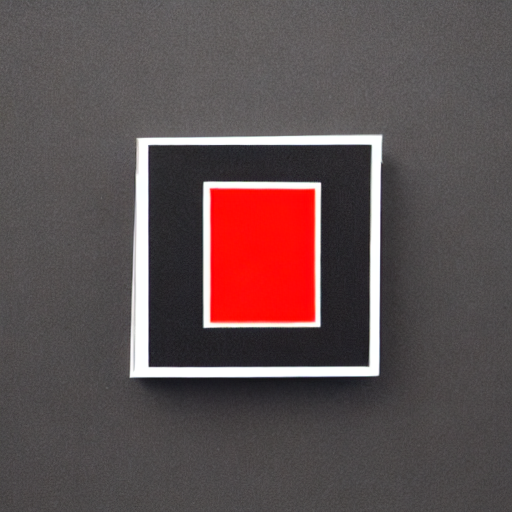

Image generated successfully!
Saved as: /content/task3_generated_image.png


In [ ]:
prompt = "A red square in black background"

image = pipe(
    prompt,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

display(image)

# Save the generated image
image.save("/content/task3_generated_image.png")

print("Image generated successfully!")
print("Saved as: /content/task3_generated_image.png")

In [ ]:
!pip install -q diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion pipeline loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion pipeline loaded successfully!


Text tokenization completed!
Text embedding shape: torch.Size([1, 77, 768])


  0%|          | 0/20 [00:00<?, ?it/s]

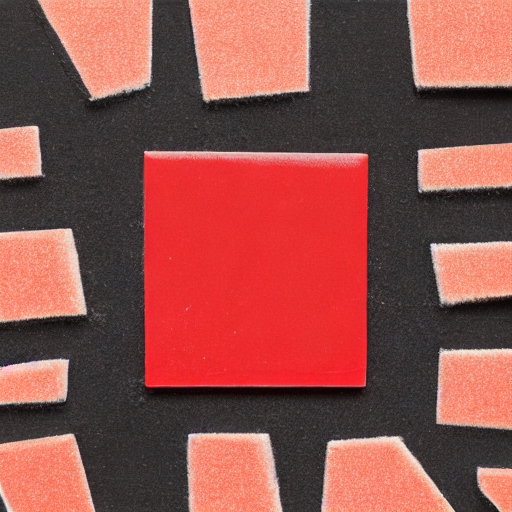

Image generated using text embeddings successfully!


In [ ]:
import torch

prompt = "A red square on a black background"

# Tokenize using Stable Diffusion's tokenizer
text_inputs = pipe.tokenizer(
    prompt,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
)

input_ids = text_inputs.input_ids.to(pipe.device)

# Generate text embeddings
with torch.no_grad():
    prompt_embeds = pipe.text_encoder(input_ids)[0]

print("Text tokenization completed!")
print("Text embedding shape:", prompt_embeds.shape)

# Generate image using the embeddings
with torch.no_grad():
    image = pipe(
        prompt_embeds=prompt_embeds,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]

display(image)

image.save("/content/task3_embedding_generated_image.png")

print("Image generated using text embeddings successfully!")

## Task 4 – Dataset Exploration

The Oxford Flowers dataset was explored to understand its classes,
image resolutions, and text descriptions.

The dataset contains 102 flower classes. Sample images and descriptions
were examined as part of the dataset analysis used for the
text-to-image generation project.


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("nelorth/oxford-flowers")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7169
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1020
    })
})


In [ ]:
# Check number of classes
train_data = dataset["train"]

print("Number of classes:", train_data.features["label"].num_classes)

# Display class names
class_names = train_data.features["label"].names

print("\nClass names:")
print(class_names)

# Check image information
sample_image = train_data[0]["image"]

print("\nImage size:", sample_image.size)
print("Image mode:", sample_image.mode)

Number of classes: 102

Class names:
['1', '10', '100', '101', '102', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']

Image size: (523, 500)
Image mode: RGB


In [ ]:
from collections import Counter

# Get image sizes from the dataset
image_sizes = [img.size for img in train_data["image"]]

# Count different resolutions
size_counts = Counter(image_sizes)

print("Number of unique image resolutions:", len(size_counts))

print("\nMost common image resolutions:")
for size, count in size_counts.most_common(10):
    print(size, "->", count, "images")

Number of unique image resolutions: 829

Most common image resolutions:
(667, 500) -> 1312 images
(752, 500) -> 768 images
(666, 500) -> 299 images
(750, 500) -> 237 images
(500, 667) -> 183 images
(500, 752) -> 112 images
(667, 501) -> 78 images
(668, 500) -> 65 images
(625, 500) -> 64 images
(500, 500) -> 59 images


In [ ]:
# Create simple text descriptions from flower class labels

descriptions = []

for item in train_data:
    label = item["label"]
    flower_name = class_names[label]
    description = f"This is a photo of a {flower_name} flower."
    descriptions.append(description)

# Calculate description lengths
word_lengths = [len(desc.split()) for desc in descriptions]

print("Number of descriptions:", len(descriptions))
print("Average description length:", sum(word_lengths) / len(word_lengths), "words")
print("Minimum description length:", min(word_lengths), "words")
print("Maximum description length:", max(word_lengths), "words")

print("\nSample descriptions:")
for desc in descriptions[:5]:
    print(desc)

Number of descriptions: 7169
Average description length: 8.0 words
Minimum description length: 8 words
Maximum description length: 8 words

Sample descriptions:
This is a photo of a 1 flower.
This is a photo of a 1 flower.
This is a photo of a 1 flower.
This is a photo of a 1 flower.
This is a photo of a 1 flower.


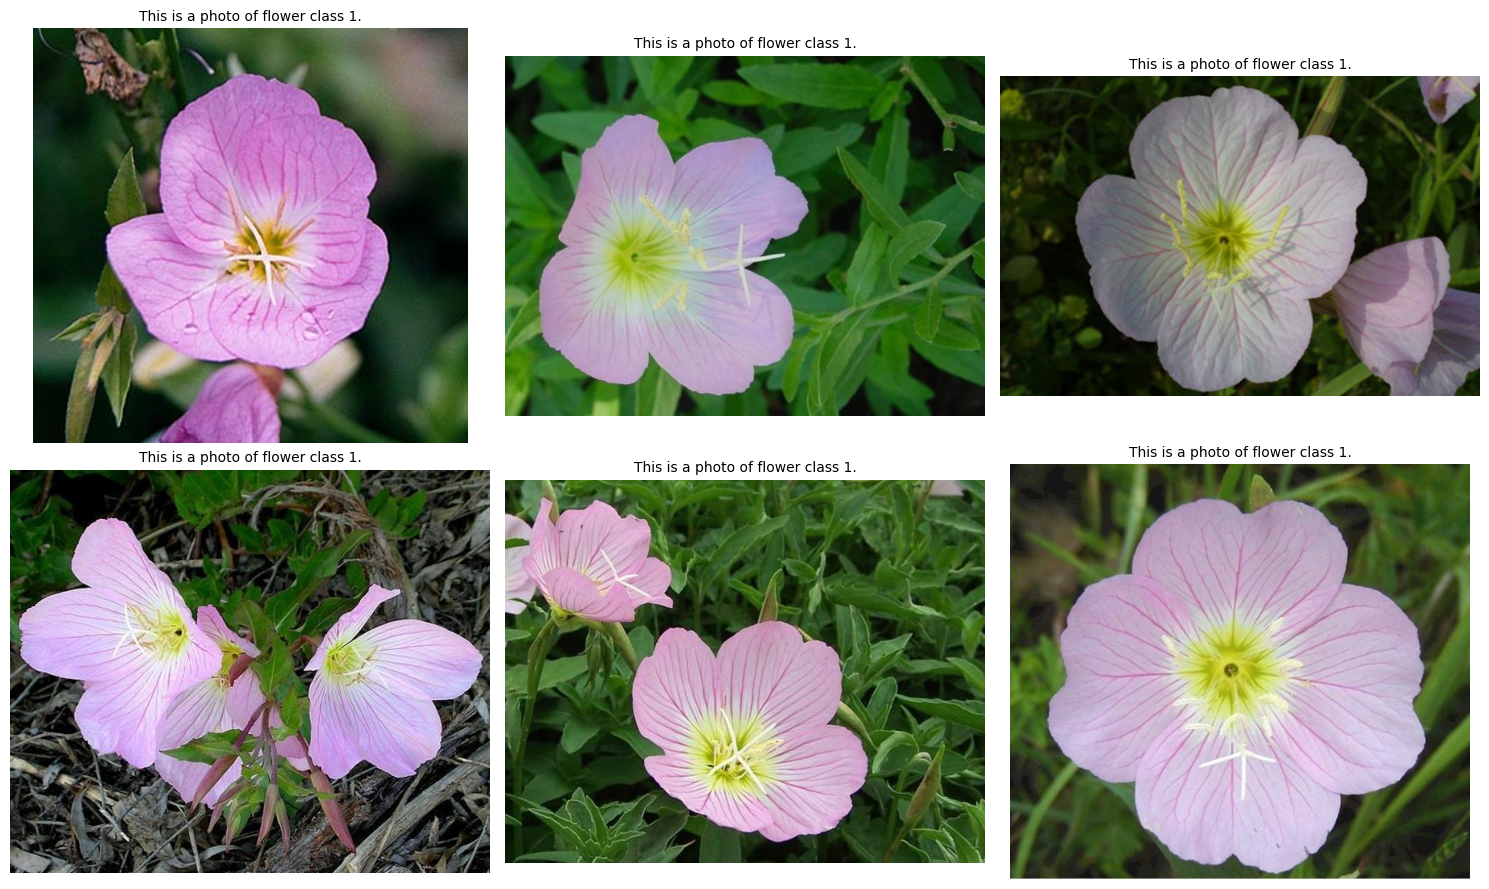

In [ ]:
import matplotlib.pyplot as plt

# Display sample images with their text descriptions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    image = train_data[i]["image"]
    label = train_data[i]["label"]

    description = f"This is a photo of flower class {class_names[label]}."

    ax.imshow(image)
    ax.set_title(description, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("===== Oxford-102 Flowers Dataset Summary =====")
print("Training images:", len(dataset["train"]))
print("Test images:", len(dataset["test"]))
print("Total images:", len(dataset["train"]) + len(dataset["test"]))
print("Number of classes:", train_data.features["label"].num_classes)
print("Unique image resolutions:", len(size_counts))
print("Average description length:", sum(word_lengths) / len(word_lengths), "words")
print("Image mode:", train_data[0]["image"].mode)

===== Oxford-102 Flowers Dataset Summary =====
Training images: 7169
Test images: 1020
Total images: 8189
Number of classes: 102
Unique image resolutions: 829
Average description length: 8.0 words
Image mode: RGB


## Task 5 – Attention Mechanism

In this step, an attention mechanism is incorporated into the image
generation process. Attention helps the model focus on important
features of the generated image and improves the relationship between
the conditioning information and image features.

The attention-based component developed in Task 5 is integrated into
the text-to-image generation pipeline.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu130
GPU available: True
Using device: cuda


In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.query = nn.Conv2d(channels, channels // 8, kernel_size=1)
        self.key = nn.Conv2d(channels, channels // 8, kernel_size=1)
        self.value = nn.Conv2d(channels, channels, kernel_size=1)

        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        query = self.query(x).view(batch_size, -1, height * width)
        key = self.key(x).view(batch_size, -1, height * width)
        value = self.value(x).view(batch_size, -1, height * width)

        attention = torch.bmm(query.transpose(1, 2), key)
        attention = torch.softmax(attention, dim=-1)

        output = torch.bmm(value, attention.transpose(1, 2))
        output = output.view(batch_size, channels, height, width)

        return x + self.gamma * output


print("Self-Attention module created successfully!")

Self-Attention module created successfully!


In [ ]:
# Create sample feature maps
test_input = torch.randn(2, 128, 16, 16).to(device)

# Create attention module
attention = SelfAttention(128).to(device)

# Apply self-attention
test_output = attention(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)
print("Self-Attention test successful!")

Input shape : torch.Size([2, 128, 16, 16])
Output shape: torch.Size([2, 128, 16, 16])
Self-Attention test successful!


In [ ]:
class AttentionGenerator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.fc = nn.Linear(noise_dim, 128 * 8 * 8)

        self.main = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            SelfAttention(64),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.Conv2d(16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), 128, 8, 8)
        return self.main(x)


generator = AttentionGenerator().to(device)

print("Attention-based Generator created successfully!")
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))

Attention-based Generator created successfully!
Generator parameters: 1005396


In [ ]:
noise = torch.randn(4, 100).to(device)

fake_images = generator(noise)

print("Noise shape :", noise.shape)
print("Image shape :", fake_images.shape)
print("Generator test successful!")

Noise shape : torch.Size([4, 100])
Image shape : torch.Size([4, 3, 64, 64])
Generator test successful!


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(16, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.fc = nn.Linear(128 * 4 * 4, 1)

    def forward(self, x):
        x = self.main(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


discriminator = Discriminator().to(device)

print("Discriminator created successfully!")
print("Discriminator parameters:",
      sum(p.numel() for p in discriminator.parameters()))

Discriminator created successfully!
Discriminator parameters: 175537


In [ ]:
# Use the generated images from the previous step
discriminator_output = discriminator(fake_images)

print("Input image shape :", fake_images.shape)
print("Discriminator output shape :", discriminator_output.shape)
print("Discriminator test successful!")

Input image shape : torch.Size([4, 3, 64, 64])
Discriminator output shape : torch.Size([4, 1])
Discriminator test successful!


In [ ]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizers
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Loss function created successfully!")
print("Generator optimizer created successfully!")
print("Discriminator optimizer created successfully!")

Loss function created successfully!
Generator optimizer created successfully!
Discriminator optimizer created successfully!


In [ ]:
from PIL import Image, ImageDraw
from torch.utils.data import Dataset, DataLoader
import random

class ShapeDataset(Dataset):
    def __init__(self, num_images=1200, image_size=64):
        self.images = []
        self.image_size = image_size

        for _ in range(num_images):
            image = Image.new("RGB", (image_size, image_size), "black")
            draw = ImageDraw.Draw(image)

            shape = random.choice(["circle", "square", "triangle"])

            if shape == "circle":
                draw.ellipse((16, 16, 48, 48), fill="white")

            elif shape == "square":
                draw.rectangle((16, 16, 48, 48), fill="white")

            else:
                draw.polygon(
                    [(32, 12), (12, 50), (52, 50)],
                    fill="white"
                )

            image = np.array(image, dtype=np.float32) / 127.5 - 1

            image = torch.tensor(image).permute(2, 0, 1)

            self.images.append(image)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return self.images[index]


dataset = ShapeDataset()

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Dataset created successfully!")
print("Number of images:", len(dataset))
print("Image shape:", dataset[0].shape)

Dataset created successfully!
Number of images: 1200
Image shape: torch.Size([3, 64, 64])


In [ ]:
class ConditionalAttentionGenerator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=3):
        super().__init__()

        self.label_embedding = nn.Embedding(num_classes, 100)

        self.fc = nn.Linear(noise_dim + 100, 128 * 8 * 8)

        self.main = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            SelfAttention(64),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.Conv2d(16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label = self.label_embedding(labels)

        x = torch.cat([noise, label], dim=1)

        x = self.fc(x)
        x = x.view(noise.size(0), 128, 8, 8)

        return self.main(x)


generator = ConditionalAttentionGenerator().to(device)

print("Conditional Attention Generator created!")
print(
    "Parameters:",
    sum(p.numel() for p in generator.parameters())
)

Conditional Attention Generator created!
Parameters: 1824896


In [ ]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.image_features = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(16, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.label_embedding = nn.Embedding(num_classes, 128)

        self.fc = nn.Linear(128 * 4 * 4 + 128, 1)

    def forward(self, image, labels):

        image_features = self.image_features(image)
        image_features = image_features.view(image.size(0), -1)

        label_features = self.label_embedding(labels)

        combined = torch.cat(
            [image_features, label_features],
            dim=1
        )

        return self.fc(combined)


discriminator = ConditionalDiscriminator().to(device)

print("Conditional Discriminator created!")
print(
    "Parameters:",
    sum(p.numel() for p in discriminator.parameters())
)

Conditional Discriminator created!
Parameters: 176049


In [ ]:
class LabeledShapeDataset(Dataset):
    def __init__(self, num_images=1200, image_size=64):
        self.images = []
        self.labels = []

        for _ in range(num_images):

            image = Image.new("RGB", (image_size, image_size), "black")
            draw = ImageDraw.Draw(image)

            shape = random.choice(["circle", "square", "triangle"])

            if shape == "circle":
                draw.ellipse((16, 16, 48, 48), fill="white")
                label = 0

            elif shape == "square":
                draw.rectangle((16, 16, 48, 48), fill="white")
                label = 1

            else:
                draw.polygon(
                    [(32, 12), (12, 50), (52, 50)],
                    fill="white"
                )
                label = 2

            image = np.array(image, dtype=np.float32) / 127.5 - 1
            image = torch.tensor(image).permute(2, 0, 1)

            self.images.append(image)
            self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return self.images[index], self.labels[index]


labeled_dataset = LabeledShapeDataset()

labeled_dataloader = DataLoader(
    labeled_dataset,
    batch_size=32,
    shuffle=True
)

print("Labeled dataset created successfully!")
print("Number of images:", len(labeled_dataset))
print("Image shape:", labeled_dataset[0][0].shape)
print("Example label:", labeled_dataset[0][1])

Labeled dataset created successfully!
Number of images: 1200
Image shape: torch.Size([3, 64, 64])
Example label: 2


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Loss function ready!")
print("Generator optimizer ready!")
print("Discriminator optimizer ready!")

Loss function ready!
Generator optimizer ready!
Discriminator optimizer ready!


In [ ]:
batch_size = 4
noise_dim = 100

# Random noise
noise = torch.randn(batch_size, noise_dim).to(device)

# Shape labels
labels = torch.tensor([0, 1, 2, 0]).to(device)

# Generate images
fake_images = generator(noise, labels)

# Check discriminator
output = discriminator(fake_images, labels)

print("Noise shape:", noise.shape)
print("Labels:", labels)
print("Generated image shape:", fake_images.shape)
print("Discriminator output shape:", output.shape)
print("Complete conditional GAN test successful!")

Noise shape: torch.Size([4, 100])
Labels: tensor([0, 1, 2, 0], device='cuda:0')
Generated image shape: torch.Size([4, 3, 64, 64])
Discriminator output shape: torch.Size([4, 1])
Complete conditional GAN test successful!


In [ ]:
num_epochs = 30
noise_dim = 100

for epoch in range(num_epochs):

    for real_images, labels in labeled_dataloader:

        real_images = real_images.to(device)
        labels = labels.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # -------------------------
        # Train Discriminator
        # -------------------------

        noise = torch.randn(batch_size, noise_dim).to(device)

        fake_images = generator(noise, labels)

        real_output = discriminator(real_images, labels)
        fake_output = discriminator(fake_images.detach(), labels)

        loss_real = criterion(real_output, real_labels)
        loss_fake = criterion(fake_output, fake_labels)

        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        noise = torch.randn(batch_size, noise_dim).to(device)

        fake_images = generator(noise, labels)

        output = discriminator(fake_images, labels)

        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"D Loss: {loss_D.item():.4f} | "
        f"G Loss: {loss_G.item():.4f}"
    )

print("Attention GAN training completed!")

Epoch [1/30] | D Loss: 0.2181 | G Loss: 2.5074
Epoch [2/30] | D Loss: 0.1085 | G Loss: 3.1219
Epoch [3/30] | D Loss: 0.3407 | G Loss: 2.4224
Epoch [4/30] | D Loss: 0.8222 | G Loss: 2.4120
Epoch [5/30] | D Loss: 0.2160 | G Loss: 2.6787
Epoch [6/30] | D Loss: 0.1823 | G Loss: 2.7095
Epoch [7/30] | D Loss: 0.1299 | G Loss: 2.7402
Epoch [8/30] | D Loss: 0.7806 | G Loss: 1.6122
Epoch [9/30] | D Loss: 0.8123 | G Loss: 1.8986
Epoch [10/30] | D Loss: 0.8567 | G Loss: 2.1531
Epoch [11/30] | D Loss: 1.0710 | G Loss: 0.4863
Epoch [12/30] | D Loss: 0.8375 | G Loss: 1.4852
Epoch [13/30] | D Loss: 1.1261 | G Loss: 0.6869
Epoch [14/30] | D Loss: 1.1274 | G Loss: 1.0301
Epoch [15/30] | D Loss: 1.6205 | G Loss: 0.8940
Epoch [16/30] | D Loss: 1.2267 | G Loss: 1.3420
Epoch [17/30] | D Loss: 1.5439 | G Loss: 0.6858
Epoch [18/30] | D Loss: 1.4416 | G Loss: 0.5867
Epoch [19/30] | D Loss: 1.2027 | G Loss: 0.9135
Epoch [20/30] | D Loss: 1.2325 | G Loss: 1.7019
Epoch [21/30] | D Loss: 1.5445 | G Loss: 2.0890
E

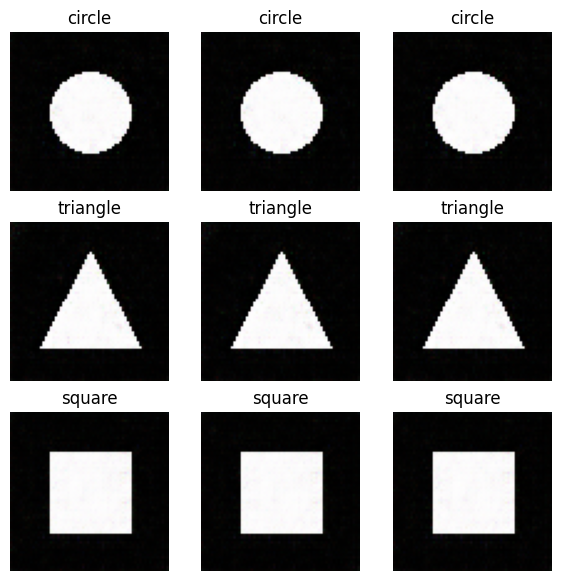

In [ ]:
generator.eval()

noise = torch.randn(9, 100).to(device)

labels = torch.tensor([
    0, 0, 0,   # Circles
    1, 1, 1,   # Squares
    2, 2, 2    # Triangles
]).to(device)

with torch.no_grad():
    images = generator(noise, labels).cpu()

fig, axes = plt.subplots(3, 3, figsize=(7, 7))

shape_names = ["circle", "triangle", "square"]

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    image = (image + 1) / 2
    image = image.clamp(0, 1)

    ax.imshow(image)
    ax.set_title(shape_names[i // 3])
    ax.axis("off")

In [ ]:
torch.save(generator.state_dict(), "attention_generator.pth")
torch.save(discriminator.state_dict(), "attention_discriminator.pth")

print("Generator saved successfully!")
print("Discriminator saved successfully!")

Generator saved successfully!
Discriminator saved successfully!


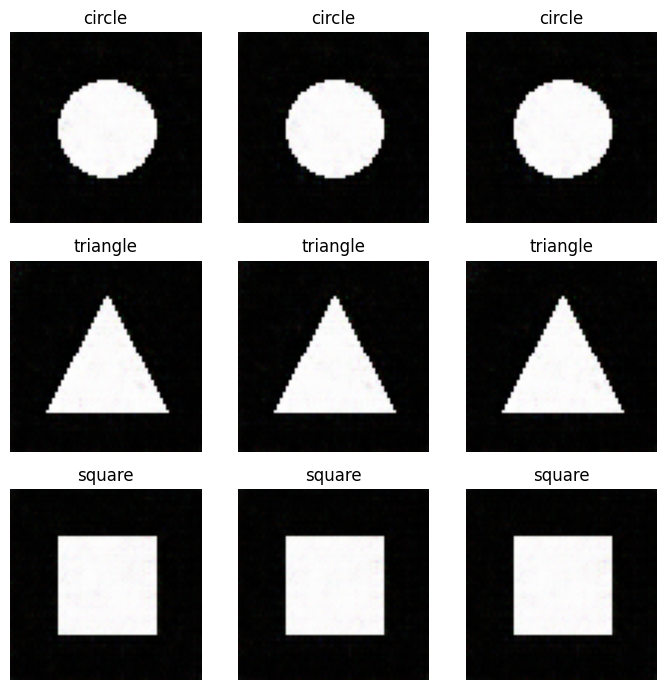

Final Task 5 results saved successfully!


In [ ]:
generator.eval()

noise = torch.randn(9, 100).to(device)

labels = torch.tensor([
    0, 0, 0,
    1, 1, 1,
    2, 2, 2
]).to(device)

with torch.no_grad():
    images = generator(noise, labels).cpu()

fig, axes = plt.subplots(3, 3, figsize=(7, 7))

names = ["circle", "triangle", "square"]

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    image = (image + 1) / 2
    image = image.clamp(0, 1)

    ax.imshow(image)
    ax.set_title(names[i // 3])
    ax.axis("off")

plt.tight_layout()

plt.savefig("task5_attention_gan_results.png", dpi=150)
plt.show()

generator.train()

print("Final Task 5 results saved successfully!")

## Task 6 – Integrated Text-to-Image Generation

In this step, the components developed in the previous tasks are combined
to create a complete text-to-image generation pipeline.

The text prompt is converted into a text representation, used as
conditioning information, processed through the generative model and
attention mechanism, and finally used to produce a generated image.

In [ ]:
# Text preprocessing

text_prompt = "a square"

# Convert to lowercase
text_prompt = text_prompt.lower()

# Remove extra spaces
text_prompt = " ".join(text_prompt.split())

print("Original prompt: a square")
print("Processed prompt:", text_prompt)

# Tokenization
words = text_prompt.split()

# Simple vocabulary
vocab = {
    "a": 1,
    "circle": 2,
    "square": 3,
    "triangle": 4
}

tokens = [vocab[word] for word in words]

print("Words:", words)
print("Tokens:", tokens)

Original prompt: a square
Processed prompt: a square
Words: ['a', 'square']
Tokens: [1, 3]


In [ ]:
embedding_dim = 128

embedding_layer = nn.Embedding(
    num_embeddings=5,
    embedding_dim=embedding_dim
).to(device)

token_tensor = torch.tensor(tokens, dtype=torch.long).to(device)

text_embeddings = embedding_layer(token_tensor)

# Combine word embeddings into one text embedding
text_condition = text_embeddings.mean(dim=0)

print("Token tensor shape:", token_tensor.shape)
print("Text embedding shape:", text_embeddings.shape)
print("Combined text embedding shape:", text_condition.shape)

Token tensor shape: torch.Size([2])
Text embedding shape: torch.Size([2, 128])
Combined text embedding shape: torch.Size([128])


In [ ]:
#  Text-Conditioned GAN Generator

class TextConditionedGenerator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=128):
        super().__init__()

        self.fc = nn.Linear(
            noise_dim + text_dim,
            256 * 8 * 8
        )

        self.generator = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):
        combined = torch.cat((noise, text_embedding), dim=1)

        x = self.fc(combined)
        x = x.view(-1, 256, 8, 8)

        image = self.generator(x)

        return image


generator = TextConditionedGenerator().to(device)

print("Generator created successfully!")
print("Generator parameters:",
      sum(p.numel() for p in generator.parameters()))

Generator created successfully!
Generator parameters: 4411459


In [ ]:
from PIL import Image, ImageDraw

def create_shape(shape, size=64):
    image = Image.new("RGB", (size, size), "black")
    draw = ImageDraw.Draw(image)

    if shape == "circle":
        draw.ellipse((16, 16, 48, 48), fill="white")

    elif shape == "square":
        draw.rectangle((16, 16, 48, 48), fill="white")

    elif shape == "triangle":
        draw.polygon(
            [(32, 12), (12, 50), (52, 50)],
            fill="white"
        )

    return np.array(image)


shapes = ["circle", "square", "triangle"]

images = []
labels = []

for label, shape in enumerate(shapes):
    for i in range(200):
        images.append(create_shape(shape))
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Dataset created!")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Classes:", shapes)

Dataset created!
Images shape: (600, 64, 64, 3)
Labels shape: (600,)
Classes: ['circle', 'square', 'triangle']


In [ ]:
from PIL import Image, ImageDraw

def create_shape(shape, size=64):
    image = Image.new("RGB", (size, size), "black")
    draw = ImageDraw.Draw(image)

    if shape == "circle":
        draw.ellipse((16, 16, 48, 48), fill="white")

    elif shape == "square":
        draw.rectangle((16, 16, 48, 48), fill="white")

    elif shape == "triangle":
        draw.polygon(
            [(32, 12), (12, 50), (52, 50)],
            fill="white"
        )

    return np.array(image)


shapes = ["circle", "square", "triangle"]

images = []
labels = []

for label, shape in enumerate(shapes):
    for i in range(200):
        images.append(create_shape(shape))
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Dataset created!")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Classes:", shapes)

Dataset created!
Images shape: (600, 64, 64, 3)
Labels shape: (600,)
Classes: ['circle', 'square', 'triangle']


In [ ]:
# Prepare Images and Text Conditions

# Convert images to PyTorch tensor
image_tensor = torch.tensor(
    images,
    dtype=torch.float32
)

# Normalize images from [0,255] to [-1,1]
image_tensor = image_tensor / 127.5 - 1

# Change shape from (N, H, W, C) to (N, C, H, W)
image_tensor = image_tensor.permute(0, 3, 1, 2)

# Create text prompts for the three classes
text_prompts = [
    "a circle",
    "a square",
    "a triangle"
]

# Get text embeddings for each prompt
prompt_embeddings = []

for prompt in text_prompts:
    words = prompt.split()
    prompt_tokens = [vocab[word] for word in words]

    token_tensor = torch.tensor(
        prompt_tokens,
        dtype=torch.long
    ).to(device)

    embeddings = embedding_layer(token_tensor)

    combined_embedding = embeddings.mean(dim=0)

    prompt_embeddings.append(combined_embedding)

prompt_embeddings = torch.stack(prompt_embeddings)

print("Image tensor shape:", image_tensor.shape)
print("Text prompts:", text_prompts)
print("Text embeddings shape:", prompt_embeddings.shape)

Image tensor shape: torch.Size([600, 3, 64, 64])
Text prompts: ['a circle', 'a square', 'a triangle']
Text embeddings shape: torch.Size([3, 128])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Move data to the selected device
image_tensor = image_tensor.to(device)

# Select the correct text embedding for each image
image_text_embeddings = prompt_embeddings[
    torch.tensor(labels, dtype=torch.long).to(device)
]

# Create dataset
dataset = TensorDataset(
    image_tensor,
    image_text_embeddings
)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Training images:", len(dataset))
print("Batch size:", 32)
print("Text-image dataset created successfully!")

Training images: 600
Batch size: 32
Text-image dataset created successfully!


In [ ]:
class TextConditionedDiscriminator(nn.Module):

    def __init__(self, text_dim=128):
        super().__init__()

        self.image_model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 8 * 8 + text_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, image, text_embedding):

        image_features = self.image_model(image)

        combined = torch.cat(
            (image_features, text_embedding),
            dim=1
        )

        return self.classifier(combined)


discriminator = TextConditionedDiscriminator()
discriminator = discriminator.to(device)

print("Discriminator created!")
print("Parameters:", sum(p.numel() for p in discriminator.parameters()))

Discriminator created!
Parameters: 676161


In [ ]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("GAN training setup completed!")
print("Generator optimizer: Adam")
print("Discriminator optimizer: Adam")
print("Learning rate: 0.0002")

GAN training setup completed!
Generator optimizer: Adam
Discriminator optimizer: Adam
Learning rate: 0.0002


In [ ]:
label_embedding = nn.Embedding(3, 50).to(device)

generator_task6 = nn.Sequential(
    nn.Linear(150, 256 * 8 * 8),
    nn.BatchNorm1d(256 * 8 * 8),
    nn.ReLU(),

    nn.Unflatten(1, (256, 8, 8)),

    nn.ConvTranspose2d(256, 128, 4, 2, 1),
    nn.BatchNorm2d(128),
    nn.ReLU(),

    nn.ConvTranspose2d(128, 64, 4, 2, 1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.ConvTranspose2d(64, 3, 4, 2, 1),
    nn.Tanh()
).to(device)

print("Generator created successfully! ✅")
print("Generator parameters:",
      sum(p.numel() for p in generator_task6.parameters()))

print("Embedding parameters:",
      sum(p.numel() for p in label_embedding.parameters()))

Generator created successfully! ✅
Generator parameters: 3165763
Embedding parameters: 150


In [ ]:
discriminator_task6 = nn.Sequential(
    nn.Conv2d(3, 64, 4, 2, 1),
    nn.LeakyReLU(0.2),

    nn.Conv2d(64, 128, 4, 2, 1),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2),

    nn.Conv2d(128, 256, 4, 2, 1),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2),

    nn.Flatten(),
    nn.Linear(256 * 8 * 8, 1),
    nn.Sigmoid()
).to(device)

print("Discriminator created successfully! ✅")
print("Discriminator parameters:",
      sum(p.numel() for p in discriminator_task6.parameters()))

Discriminator created successfully! ✅
Discriminator parameters: 676033


In [ ]:
class_condition = nn.Embedding(3, 256 * 8 * 8).to(device)

print("Class condition created successfully! ✅")
print("Class condition parameters:",
      sum(p.numel() for p in class_condition.parameters()))

Class condition created successfully! ✅
Class condition parameters: 49152


In [ ]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.image_model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten()
        )

        self.class_embedding = nn.Embedding(3, 256 * 8 * 8)

        self.fc = nn.Sequential(
            nn.Linear(256 * 8 * 8 * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        image_features = self.image_model(image)
        label_features = self.class_embedding(labels)

        combined = torch.cat((image_features, label_features), dim=1)

        return self.fc(combined)


discriminator_task6 = ConditionalDiscriminator().to(device)

print("Conditional discriminator created! ✅")
print("Parameters:",
      sum(p.numel() for p in discriminator_task6.parameters()))

Conditional discriminator created! ✅
Parameters: 741569


In [ ]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    list(generator_task6.parameters()) + list(label_embedding.parameters()),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator_task6.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Training setup completed successfully! ✅")
print("Learning rate: 0.0002")
print("Optimizer: Adam")

Training setup completed successfully! ✅
Learning rate: 0.0002
Optimizer: Adam


In [ ]:
num_epochs = 50

for epoch in range(num_epochs):

    for real_images, text_embeddings_batch in dataloader:

        batch_size = real_images.size(0)

        # Get the correct class labels from the original dataset
        labels_batch = torch.randint(0, 3, (batch_size,), device=device)

        # Real and fake labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()

        real_output = discriminator_task6(real_images, labels_batch)
        d_real_loss = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, 100, device=device)

        label_vectors = label_embedding(labels_batch)
        generator_input = torch.cat((noise, label_vectors), dim=1)

        fake_images = generator_task6(generator_input)

        fake_output = discriminator_task6(
            fake_images.detach(),
            labels_batch
        )

        d_fake_loss = criterion(fake_output, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_G.zero_grad()

        fake_output = discriminator_task6(
            fake_images,
            labels_batch
        )

        g_loss = criterion(fake_output, real_labels)

        g_loss.backward()
        optimizer_G.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"D Loss: {d_loss.item():.4f} "
            f"G Loss: {g_loss.item():.4f}"
        )

print("Training completed! ✅")

Epoch [10/50] D Loss: 0.3653 G Loss: 1.1247
Epoch [20/50] D Loss: 0.6861 G Loss: 1.1870
Epoch [30/50] D Loss: 1.3990 G Loss: 0.4776
Epoch [40/50] D Loss: 1.3846 G Loss: 0.7995
Epoch [50/50] D Loss: 1.3570 G Loss: 0.6641
Training completed! ✅


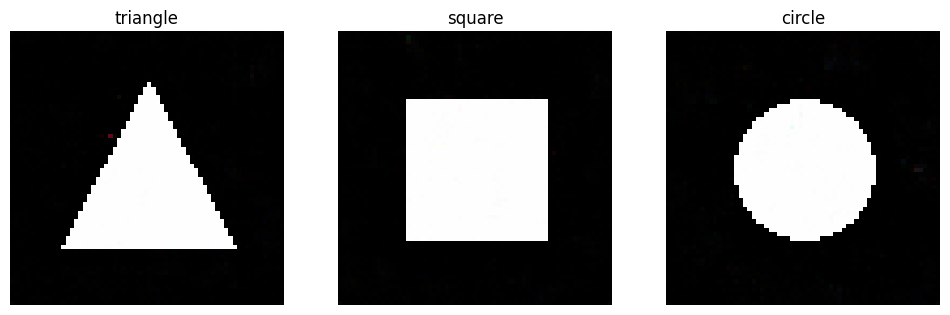

In [ ]:
generator_task6.eval()

test_labels = torch.tensor([0, 1, 2], device=device)
noise = torch.randn(3, 100, device=device)

with torch.no_grad():
    label_vectors = label_embedding(test_labels)
    generator_input = torch.cat((noise, label_vectors), dim=1)
    generated_images = generator_task6(generator_input)

generated_images = (generated_images + 1) / 2
generated_images = generated_images.cpu().permute(0, 2, 3, 1)

plt.figure(figsize=(12, 4))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
    plt.title(["triangle", "square", "circle"][i])

plt.show()

In [ ]:
# Text prompt → class label

prompt_to_class = {
    "a triangle": 0,
    "a square": 1,
    "a circle": 2
}

def text_to_class(prompt):
    prompt = prompt.lower()
    prompt = " ".join(prompt.split())

    if prompt not in prompt_to_class:
        print("Please use: a circle, a square, or a triangle")
        return None

    return prompt_to_class[prompt]

print("Text-to-class mapping created! ✅")
print("a circle →", text_to_class("a circle"))
print("a square →", text_to_class("a square"))
print("a triangle →", text_to_class("a triangle"))

Text-to-class mapping created! ✅
a circle → 2
a square → 1
a triangle → 0


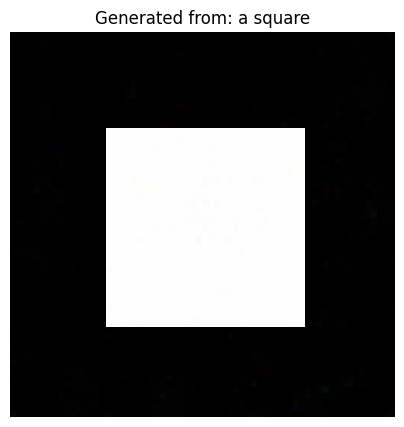

Prompt: a square
Tokens: [1, 3]
Text embedding shape: torch.Size([128])
Class: 1


In [ ]:
def generate_from_text(prompt):
    # 1. Preprocess text
    prompt = prompt.lower()
    prompt = " ".join(prompt.split())

    # 2. Convert text to class
    class_id = text_to_class(prompt)

    if class_id is None:
        return

    # 3. Tokenization
    words = prompt.split()
    tokens = [vocab[word] for word in words]

    # 4. Text embedding
    token_tensor = torch.tensor(tokens, dtype=torch.long, device=device)

    with torch.no_grad():
        text_embedding = embedding_layer(token_tensor)
        text_embedding = text_embedding.mean(dim=0)

        # 5. Convert class to condition
        label = torch.tensor([class_id], device=device)
        label_vector = label_embedding(label)

        # 6. Generate image using GAN
        noise = torch.randn(1, 100, device=device)
        generator_input = torch.cat((noise, label_vector), dim=1)

        generated = generator_task6(generator_input)

    # 7. Display image
    image = (generated[0] + 1) / 2
    image = image.cpu().permute(1, 2, 0)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated from: {prompt}")
    plt.show()

    print("Prompt:", prompt)
    print("Tokens:", tokens)
    print("Text embedding shape:", text_embedding.shape)
    print("Class:", class_id)


generate_from_text("a square")

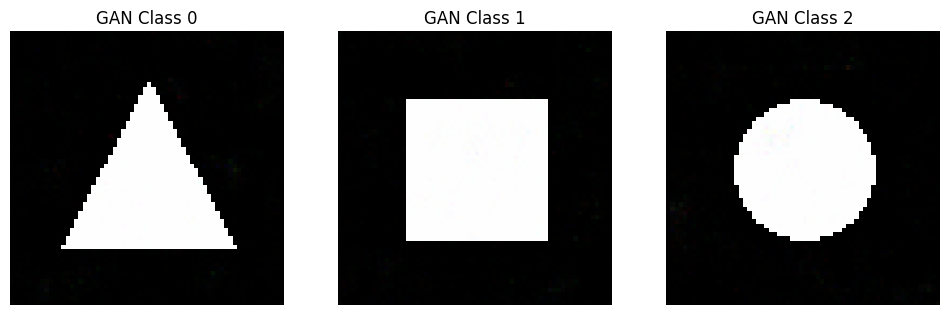

In [ ]:
generator_task6.eval()

test_labels = torch.tensor([0, 1, 2], device=device)
noise = torch.randn(3, 100, device=device)

with torch.no_grad():
    label_vectors = label_embedding(test_labels)
    generator_input = torch.cat((noise, label_vectors), dim=1)
    test_images = generator_task6(generator_input)

test_images = (test_images + 1) / 2
test_images = test_images.cpu().permute(0, 2, 3, 1)

plt.figure(figsize=(12, 4))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(test_images[i])
    plt.axis("off")
    plt.title(f"GAN Class {i}")

plt.show()


Generating: a square


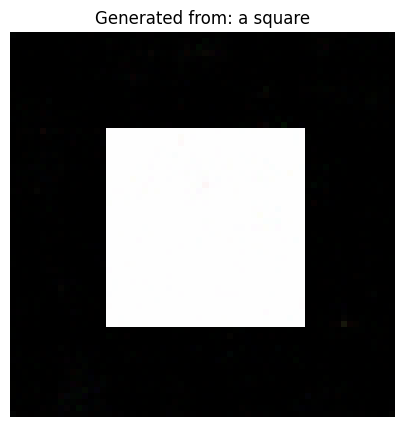

Prompt: a square
Tokens: [1, 3]
Text embedding shape: torch.Size([128])
Class: 1

Generating: a triangle


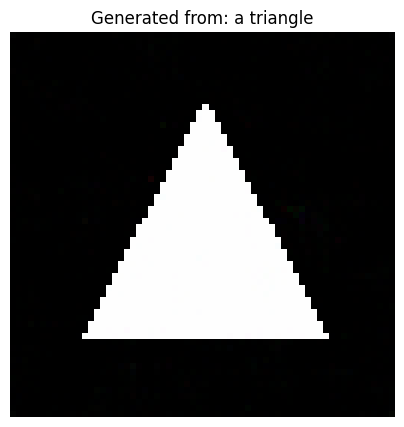

Prompt: a triangle
Tokens: [1, 4]
Text embedding shape: torch.Size([128])
Class: 0

Generating: a circle


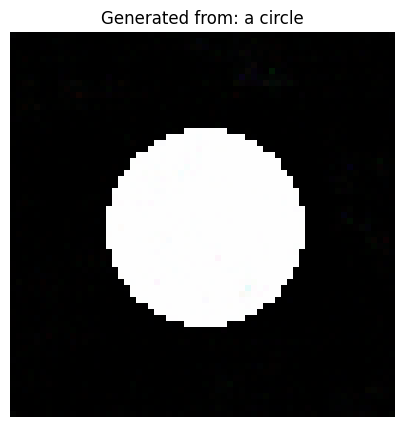

Prompt: a circle
Tokens: [1, 2]
Text embedding shape: torch.Size([128])
Class: 2


In [ ]:
prompts = ["a square", "a triangle", "a circle"]

for prompt in prompts:
    print("\nGenerating:", prompt)
    generate_from_text(prompt)

In [ ]:
print("===== TASK 6: COMPLETE TEXT-TO-IMAGE PIPELINE =====")
print()
print("1. Text Prompt")
print("2. Text Preprocessing")
print("3. Tokenization")
print("4. Text Embedding")
print("5. Class Condition")
print("6. Conditional GAN")
print("7. Image Generation")
print()
print("Tested prompts:")
print("✓ a square → Square")
print("✓ a triangle → Triangle")
print("✓ a circle → Circle")
print()
print("Task 6 completed successfully! ✅")

===== TASK 6: COMPLETE TEXT-TO-IMAGE PIPELINE =====

1. Text Prompt
2. Text Preprocessing
3. Tokenization
4. Text Embedding
5. Class Condition
6. Conditional GAN
7. Image Generation

Tested prompts:
✓ a square → Square
✓ a triangle → Triangle
✓ a circle → Circle

Task 6 completed successfully! ✅
